In [8]:
import kagglehub
import os
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("tanayatipre/store-sales-forecasting-dataset")

print("Path to dataset files:", path)
df = pd.read_csv(path + '/' + os.listdir(path)[0], encoding='latin1')

Path to dataset files: /Users/rafael/.cache/kagglehub/datasets/tanayatipre/store-sales-forecasting-dataset/versions/1


In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [14]:
df.sample

<bound method NDFrame.sample of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
3          6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
4         11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
...      ...             ...         ...         ...             ...   
2116    9963  CA-2015-168088   3/19/2015   3/22/2015     First Class   
2117    9965  CA-2016-146374   12/5/2016  12/10/2016    Second Class   
2118    9981  US-2015-151435    9/6/2015    9/9/2015    Second Class   
2119    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
2120    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   

     Customer ID     Customer Name      Segment        Country  \
0       CG-12520       Claire Gute   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm
from prophet import Prophet
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid

warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA PREPROCESSING
# ==========================================
def preprocess_data(df, target_col='Sales', date_col='Order Date', freq='MS'):
    """Aggregates data to a regular frequency (e.g., Monthly Start)."""
    df[date_col] = pd.to_datetime(df[date_col])
    # Keep only date and target, group by date and sum
    df_ts = df.groupby(date_col)[target_col].sum().reset_index()
    # Set index and resample to ensure continuous timeline
    df_ts.set_index(date_col, inplace=True)
    df_ts = df_ts.resample(freq).sum()
    df_ts[target_col] = df_ts[target_col].fillna(0) # Fill missing months
    
    return df_ts

# ==========================================
# 2. TIME SERIES EDA
# ==========================================
def perform_eda(df_ts, target_col='Sales'):
    """Performs seasonal decomposition and ADF stationarity test."""
    print("--- Time Series EDA ---")
    
    # Trend & Seasonality Decomposition
    decomposition = seasonal_decompose(df_ts[target_col], model='additive')
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle('Seasonal Decomposition', fontsize=14)
    plt.show()
    
    # Stationarity Check (Augmented Dickey-Fuller)
    result = adfuller(df_ts[target_col])
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Conclusion: Data is STATIONARY (Reject Null Hypothesis)")
    else:
        print("Conclusion: Data is NON-STATIONARY (Fail to reject Null Hypothesis)")

# ==========================================
# 3. FEATURE ENGINEERING FOR ML MODELS
# ==========================================
def create_ml_features(df_ts, target_col='Sales', lags=3):
    """Creates lag and datetime features for XGBoost & LightGBM."""
    df_ml = df_ts.copy()
    df_ml['Month'] = df_ml.index.month
    df_ml['Year'] = df_ml.index.year
    
    for i in range(1, lags + 1):
        df_ml[f'Lag_{i}'] = df_ml[target_col].shift(i)
        
    df_ml.dropna(inplace=True)
    return df_ml

# ==========================================
# 4. MODELING & GRID SEARCH
# ==========================================
def run_forecasting_pipeline(df_ts, test_size=12):
    """Runs grid search across models and compares MAPE."""
    train = df_ts.iloc[:-test_size]
    test = df_ts.iloc[-test_size:]
    
    results = {}
    
    # --- 1. AutoARIMA (Built-in Grid Search) ---
    print("\nTraining AutoARIMA...")
    arima_model = pm.auto_arima(train['Sales'], seasonal=True, m=12, 
                                stepwise=True, suppress_warnings=True, 
                                error_action="ignore")
    results['AutoARIMA'] = mean_absolute_percentage_error(test['Sales'], arima_model.predict(n_periods=test_size))
    
    # --- 2. Exponential Smoothing (Grid Search) ---
    print("Training Exponential Smoothing...")
    hw_params = {'trend': ['add', 'mul', None], 'seasonal': ['add', 'mul', None]}
    best_hw_mape = float('inf')
    for p in ParameterGrid(hw_params):
        try:
            hw = ExponentialSmoothing(train['Sales'], trend=p['trend'], seasonal=p['seasonal'], seasonal_periods=12).fit(optimized=True)
            preds = hw.forecast(len(test))
            mape = mean_absolute_percentage_error(test['Sales'], preds)
            if mape < best_hw_mape:
                best_hw_mape = mape
        except:
            continue
    results['Exponential_Smoothing'] = best_hw_mape

    # --- 3. Prophet (Grid Search) ---
    print("Training Prophet...")
    prophet_df = train.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    test_prophet_df = test.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    
    prophet_params = {'changepoint_prior_scale': [0.01, 0.1], 'seasonality_prior_scale': [1.0, 10.0]}
    best_prophet_mape = float('inf')
    
    for p in ParameterGrid(prophet_params):
        m = Prophet(changepoint_prior_scale=p['changepoint_prior_scale'], 
                    seasonality_prior_scale=p['seasonality_prior_scale'])
        m.fit(prophet_df)
        future = m.make_future_dataframe(periods=test_size, freq='MS')
        forecast = m.predict(future)
        preds = forecast['yhat'].tail(test_size)
        mape = mean_absolute_percentage_error(test_prophet_df['y'], preds)
        if mape < best_prophet_mape:
            best_prophet_mape = mape
    results['Prophet'] = best_prophet_mape

    # --- ML Models (XGBoost & LightGBM) ---
    df_ml = create_ml_features(df_ts, lags=3)
    train_ml = df_ml.iloc[:-test_size]
    test_ml = df_ml.iloc[-test_size:]
    
    X_train, y_train = train_ml.drop(columns=['Sales']), train_ml['Sales']
    X_test, y_test = test_ml.drop(columns=['Sales']), test_ml['Sales']
    
    ml_params = {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}

    # --- 4. XGBoost ---
    print("Training XGBoost...")
    best_xgb_mape = float('inf')
    for p in ParameterGrid(ml_params):
        model = xgb.XGBRegressor(**p, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mape = mean_absolute_percentage_error(y_test, preds)
        if mape < best_xgb_mape:
            best_xgb_mape = mape
    results['XGBoost'] = best_xgb_mape

    # --- 5. LightGBM ---
    print("Training LightGBM...")
    best_lgb_mape = float('inf')
    for p in ParameterGrid(ml_params):
        model = lgb.LGBMRegressor(**p, random_state=42, verbose=-1)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mape = mean_absolute_percentage_error(y_test, preds)
        if mape < best_lgb_mape:
            best_lgb_mape = mape
    results['LightGBM'] = best_lgb_mape

    # --- Comparison ---
    print("\n===================================")
    print(" MODEL COMPARISON (Best MAPE)")
    print("===================================")
    comparison_df = pd.DataFrame.from_dict(results, orient='index', columns=['MAPE'])
    comparison_df = comparison_df.sort_values(by='MAPE')
    print(comparison_df)
    
    return comparison_df



def plot_forecasts(df_ts, test_preds, future_preds, model_name="Best Model"):
    """
    Plots historical data, test set predictions, and future 12-month forecast.
    
    Parameters:
    - df_ts: Original time series DataFrame (contains 'Sales').
    - test_preds: Predictions for the test set (must have DatetimeIndex matching test set).
    - future_preds: Predictions for the future 12 months (must have future DatetimeIndex).
    - model_name: String name of the model being plotted.
    """
    plt.figure(figsize=(15, 7))
    
    # 1. Plot Actual Historical Data (Train + Test)
    plt.plot(df_ts.index, df_ts['Sales'], label='Actual Sales', color='black', linewidth=1.5)
    
    # 2. Plot Test Predictions
    plt.plot(test_preds.index, test_preds, label=f'Test Predictions ({model_name})', 
             color='blue', linestyle='--', linewidth=2)
    
    # 3. Plot Future Forecast
    plt.plot(future_preds.index, future_preds, label=f'Future 12-Month Forecast', 
             color='red', linestyle='-.', linewidth=2)
    
    # Formatting
    plt.title(f'Sales Forecasting & Future Projections - {model_name}', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add a vertical line marking the end of historical data
    plt.axvline(x=df_ts.index[-1], color='gray', linestyle=':', alpha=0.7)
    plt.text(df_ts.index[-1], plt.ylim()[1]*0.95, ' Future Forecast Starts \n', color='gray', ha='left')
    
    plt.tight_layout()
    plt.show()




    

In [22]:
df_ts = preprocess_data(df)

--- Time Series EDA ---


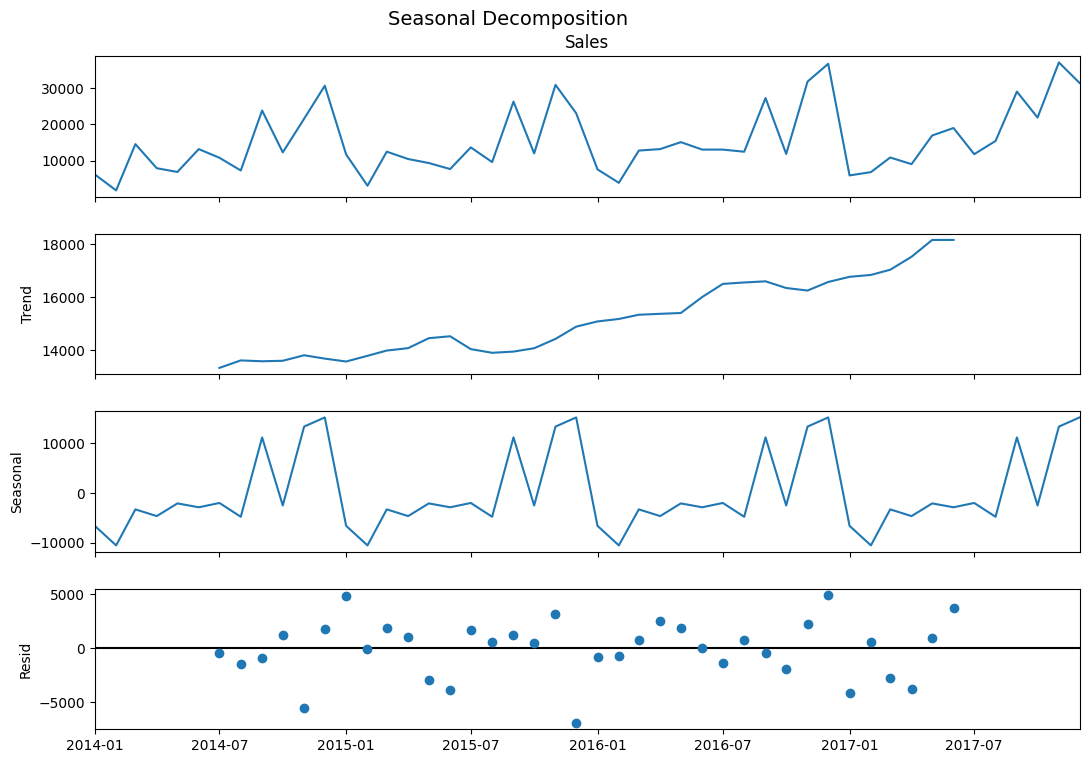

ADF Statistic: -4.6990
p-value: 0.0001
Conclusion: Data is STATIONARY (Reject Null Hypothesis)


In [ ]:
perform_eda(df_ts)


In [18]:
comparison_results = run_forecasting_pipeline(df_ts, test_size=12)


Training AutoARIMA...
Training Exponential Smoothing...
Training Prophet...


11:44:51 - cmdstanpy - INFO - Chain [1] start processing
11:44:51 - cmdstanpy - INFO - Chain [1] done processing
11:44:53 - cmdstanpy - INFO - Chain [1] start processing
11:44:53 - cmdstanpy - INFO - Chain [1] done processing
11:44:53 - cmdstanpy - INFO - Chain [1] start processing
11:44:53 - cmdstanpy - INFO - Chain [1] done processing
11:44:53 - cmdstanpy - INFO - Chain [1] start processing
11:44:53 - cmdstanpy - INFO - Chain [1] done processing


Training XGBoost...
Training LightGBM...

 MODEL COMPARISON (Best MAPE)
                           MAPE
AutoARIMA              0.258866
XGBoost                0.277023
Prophet                0.295359
Exponential_Smoothing  0.301795
LightGBM               0.529052


13:04:52 - cmdstanpy - INFO - Chain [1] start processing
13:04:52 - cmdstanpy - INFO - Chain [1] done processing
13:04:52 - cmdstanpy - INFO - Chain [1] start processing
13:04:52 - cmdstanpy - INFO - Chain [1] done processing


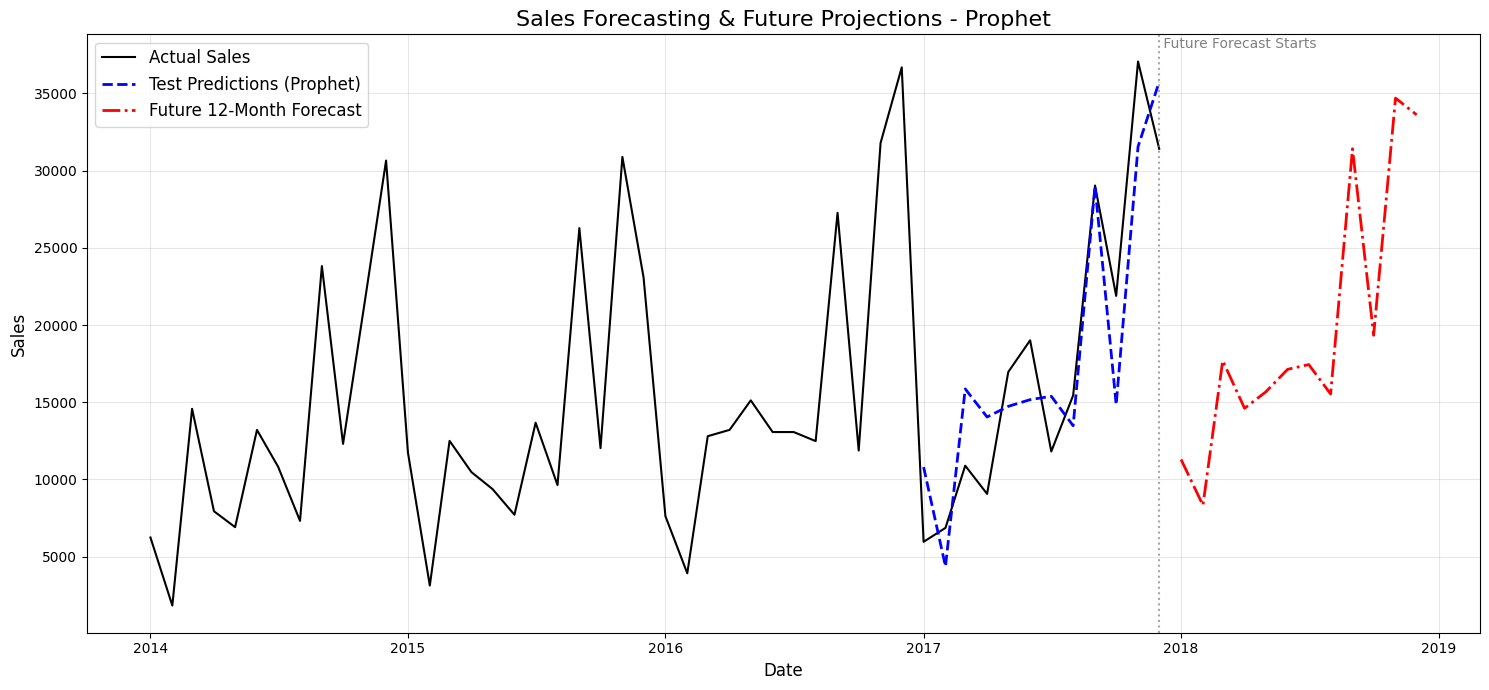

In [20]:

test_size = 12
train = df_ts.iloc[:-test_size]
test = df_ts.iloc[-test_size:]

# --- 1. Get Test Predictions (Using best params found in grid search) ---
prophet_train = train.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
best_model_test = Prophet(changepoint_prior_scale=0.1, seasonality_prior_scale=10.0) # Insert best params
best_model_test.fit(prophet_train)

future_test = best_model_test.make_future_dataframe(periods=test_size, freq='MS')
test_forecast = best_model_test.predict(future_test)

# Format test predictions to have the correct DatetimeIndex
test_preds = test_forecast['yhat'].tail(test_size)
test_preds.index = test.index 

# --- 2. Get Future 12 Months (Retrain on FULL dataset) ---
prophet_full = df_ts.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
best_model_future = Prophet(changepoint_prior_scale=0.1, seasonality_prior_scale=10.0)
best_model_future.fit(prophet_full)

future_12m = best_model_future.make_future_dataframe(periods=12, freq='MS')
future_forecast = best_model_future.predict(future_12m)

# Format future predictions to have the correct DatetimeIndex
future_preds = future_forecast['yhat'].tail(12)
future_preds.index = future_12m['ds'].tail(12)

# --- 3. Call the Plotting Component ---
plot_forecasts(df_ts, test_preds, future_preds, model_name="Prophet")

## Forecasting with plots

In [26]:
def generate_and_plot_all_models(df_ts, test_size=12, future_steps=12, lags=3):
    """
    Trains each model on the train set (for test predictions) and the full set 
    (for future predictions), then plots the results.
    """
    train = df_ts.iloc[:-test_size]
    test = df_ts.iloc[-test_size:]
    
    # ---------------------------------------------------------
    # 1. AutoARIMA
    # ---------------------------------------------------------
    print("Processing AutoARIMA...")
    # Test predictions
    arima_train = pm.auto_arima(train['Sales'], seasonal=True, m=12, suppress_warnings=True)
    test_preds_arima = pd.Series(arima_train.predict(n_periods=test_size).values, index=test.index)
    
    # Future predictions
    arima_full = pm.auto_arima(df_ts['Sales'], seasonal=True, m=12, suppress_warnings=True)
    future_index = pd.date_range(start=df_ts.index[-1] + pd.DateOffset(months=1), periods=future_steps, freq='MS')
    future_preds_arima = pd.Series(arima_full.predict(n_periods=future_steps).values, index=future_index)
    
    plot_forecasts(df_ts, test_preds_arima, future_preds_arima, model_name="AutoARIMA")

    # ---------------------------------------------------------
    # 2. Exponential Smoothing
    # ---------------------------------------------------------
    print("Processing Exponential Smoothing...")
    # Test predictions
    hw_train = ExponentialSmoothing(train['Sales'], trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
    test_preds_hw = hw_train.forecast(test_size)
    
    # Future predictions
    hw_full = ExponentialSmoothing(df_ts['Sales'], trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
    future_preds_hw = hw_full.forecast(future_steps)
    
    plot_forecasts(df_ts, test_preds_hw, future_preds_hw, model_name="Exponential Smoothing")

    # ---------------------------------------------------------
    # 3. Prophet
    # ---------------------------------------------------------
    print("Processing Prophet...")
    # Test predictions
    prophet_train_df = train.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    m_train = Prophet(seasonality_mode='multiplicative').fit(prophet_train_df)
    future_test = m_train.make_future_dataframe(periods=test_size, freq='MS')
    test_preds_prophet = m_train.predict(future_test)['yhat'].tail(test_size)
    test_preds_prophet.index = test.index
    
    # Future predictions
    prophet_full_df = df_ts.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    m_full = Prophet(seasonality_mode='multiplicative').fit(prophet_full_df)
    future_full = m_full.make_future_dataframe(periods=future_steps, freq='MS')
    future_preds_prophet = m_full.predict(future_full)['yhat'].tail(future_steps)
    future_preds_prophet.index = future_index
    
    plot_forecasts(df_ts, test_preds_prophet, future_preds_prophet, model_name="Prophet")

    # ---------------------------------------------------------
    # 4 & 5. Machine Learning Models (XGBoost & LightGBM)
    # ---------------------------------------------------------
    # Prepare features for ML
    df_ml = create_ml_features(df_ts, lags=lags)
    train_ml = df_ml.iloc[:-test_size]
    
    X_train, y_train = train_ml.drop(columns=['Sales']), train_ml['Sales']
    X_full, y_full = df_ml.drop(columns=['Sales']), df_ml['Sales']

    models = {
        "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
        "LightGBM": lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbose=-1)
    }

    for name, model in models.items():
        print(f"Processing {name}...")
        
        # Test predictions (using recursive function to prevent data leakage)
        model.fit(X_train, y_train)
        test_preds_ml = recursive_ml_forecast(model, train['Sales'], steps=test_size, lags=lags)
        test_preds_ml.index = test.index 
        
        # Future predictions
        model.fit(X_full, y_full)
        future_preds_ml = recursive_ml_forecast(model, df_ts['Sales'], steps=future_steps, lags=lags)
        
        plot_forecasts(df_ts, test_preds_ml, future_preds_ml, model_name=name)


def recursive_ml_forecast(model, historical_series, steps, lags=3):
    """
    Recursively predicts future steps for ML models by using its own 
    predictions as new lag features.
    """
    # Determine the start date for future predictions
    last_date = historical_series.index[-1]
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=steps, freq='MS')
    
    # Keep a working copy of the series to append predictions
    history = historical_series.copy()
    preds = []
    
    for date in future_dates:
        # Construct the feature row for the current step
        features = {'Month': [date.month], 'Year': [date.year]}
        for i in range(1, lags + 1):
            features[f'Lag_{i}'] = [history.iloc[-i]]
            
        X_step = pd.DataFrame(features)
        
        # Predict the next step
        pred = model.predict(X_step)[0]
        preds.append(pred)
        
        # Append prediction to history to use as a lag in the next iteration
        history.loc[date] = pred
        
    return pd.Series(preds, index=future_dates)


Processing AutoARIMA...


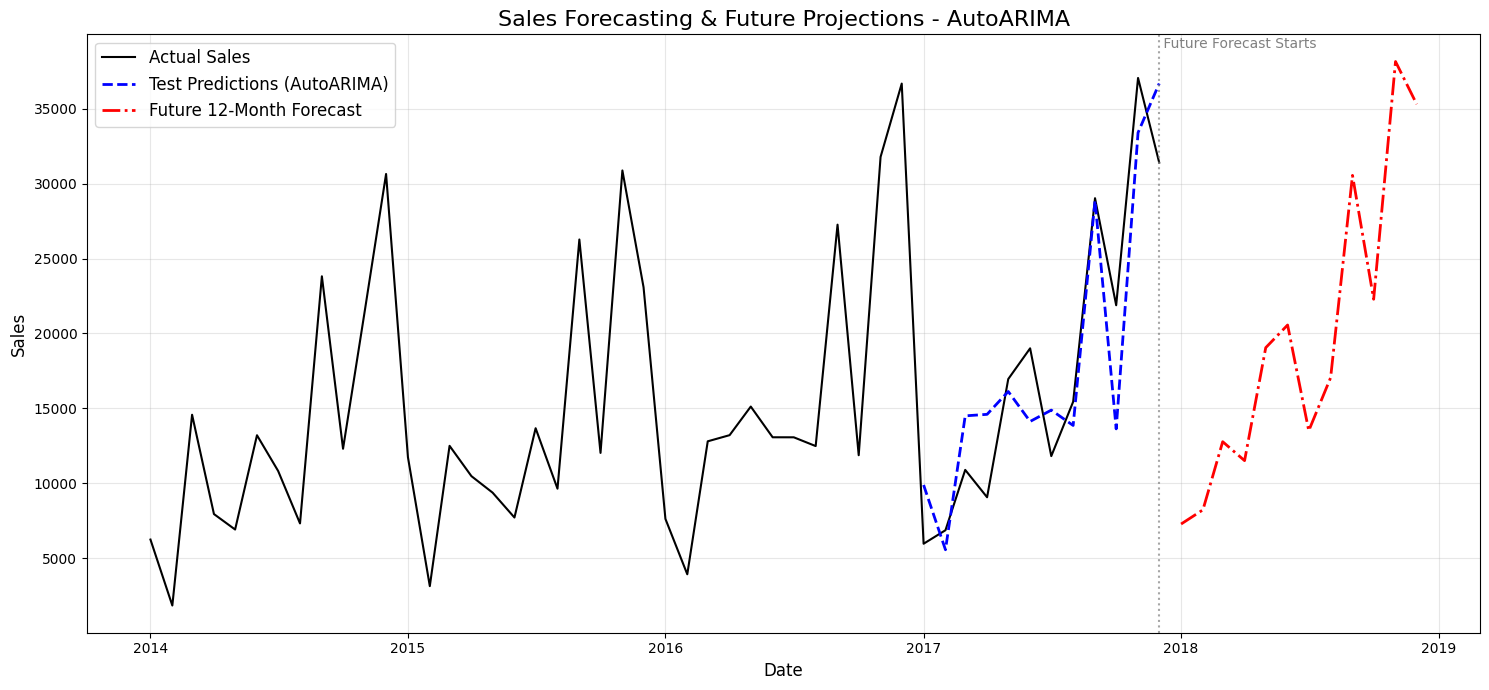

Processing Exponential Smoothing...


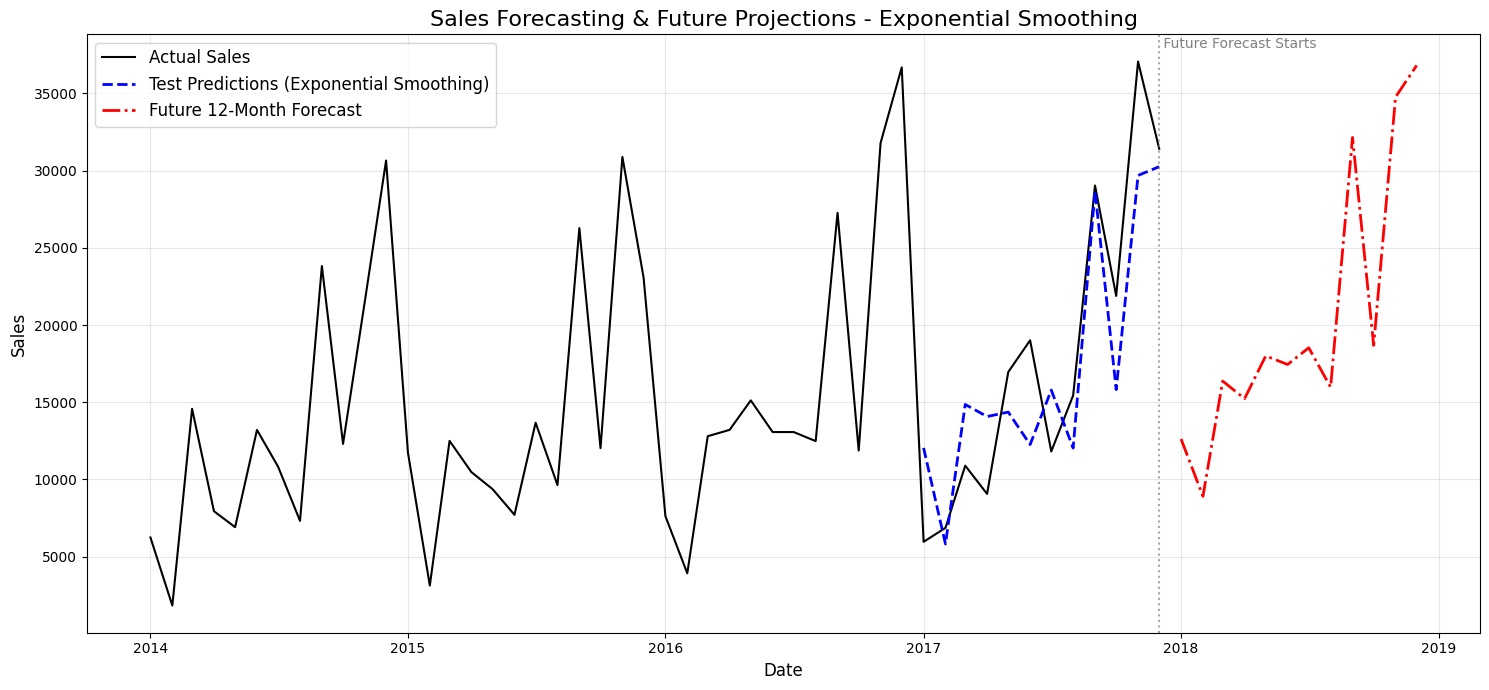

13:28:53 - cmdstanpy - INFO - Chain [1] start processing


Processing Prophet...


13:28:53 - cmdstanpy - INFO - Chain [1] done processing
13:28:53 - cmdstanpy - INFO - Chain [1] start processing
13:28:53 - cmdstanpy - INFO - Chain [1] done processing


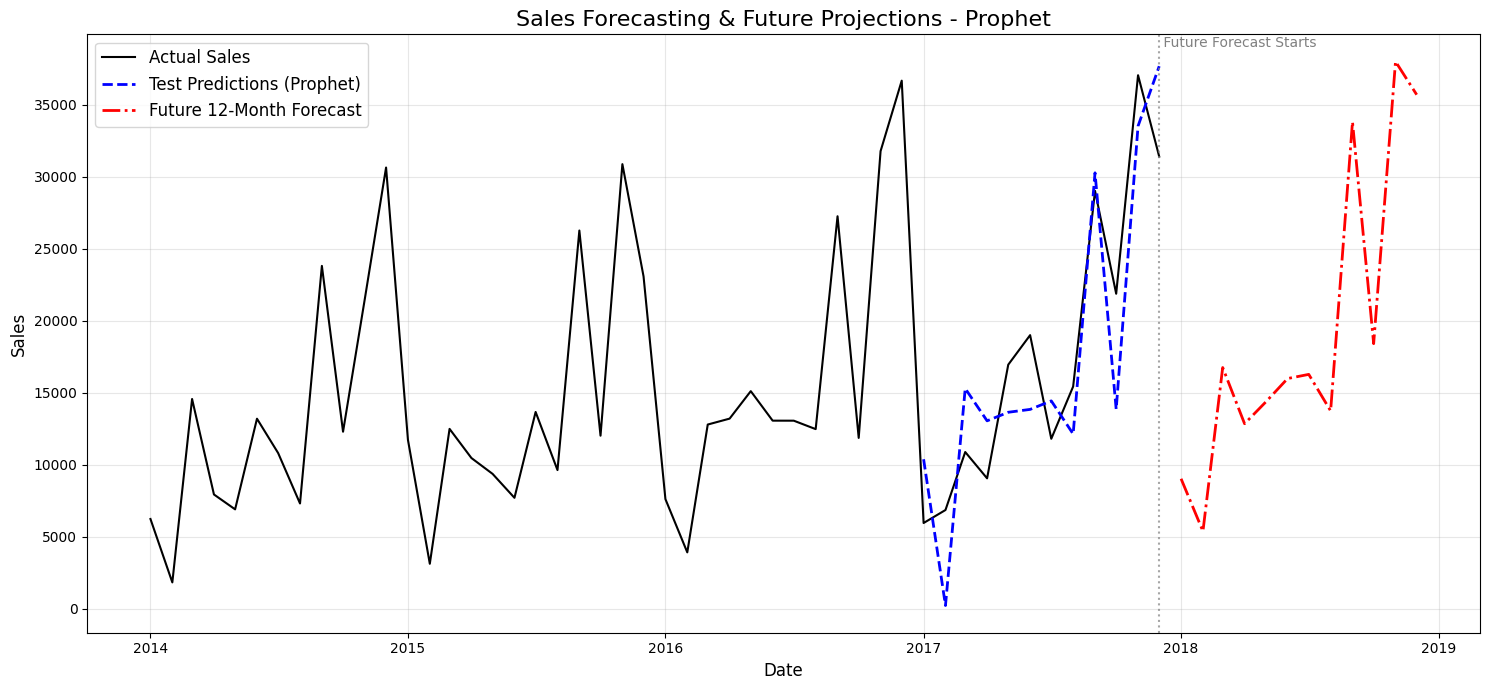

Processing XGBoost...


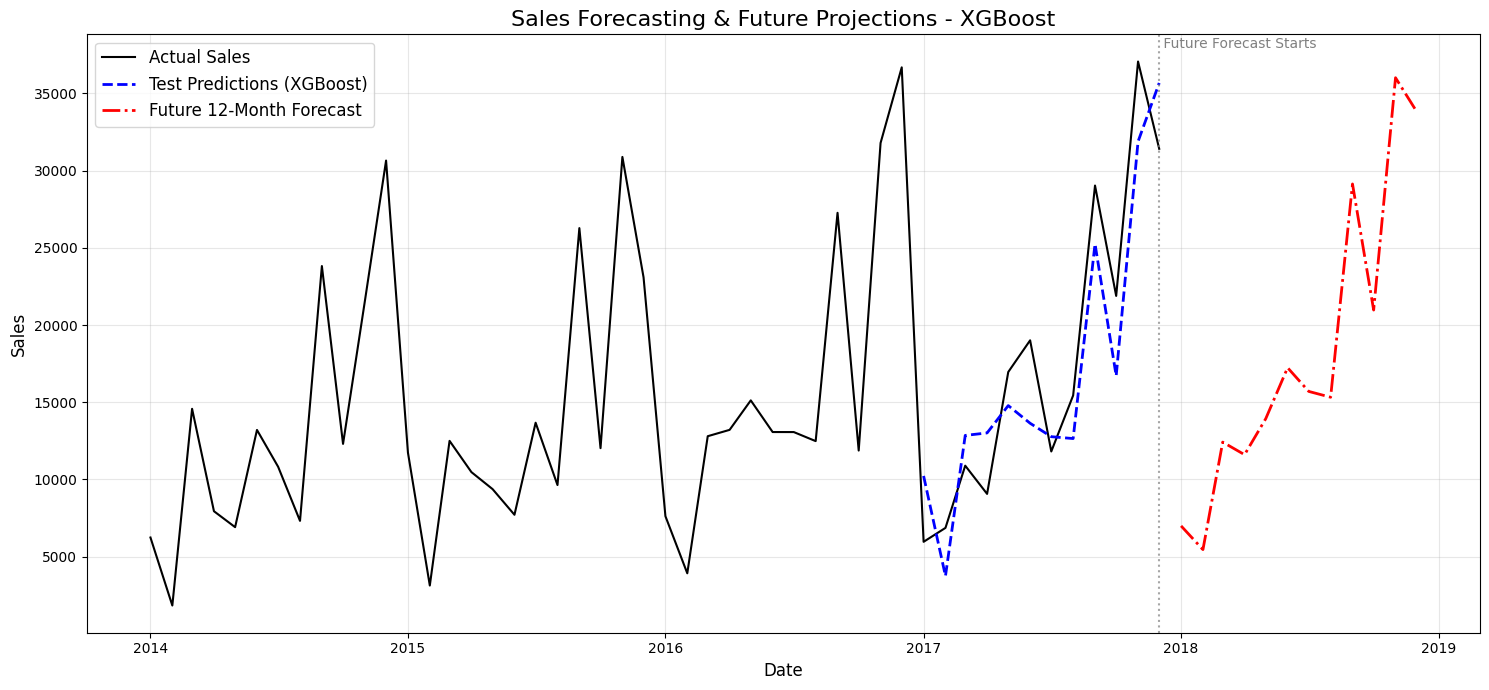

Processing LightGBM...


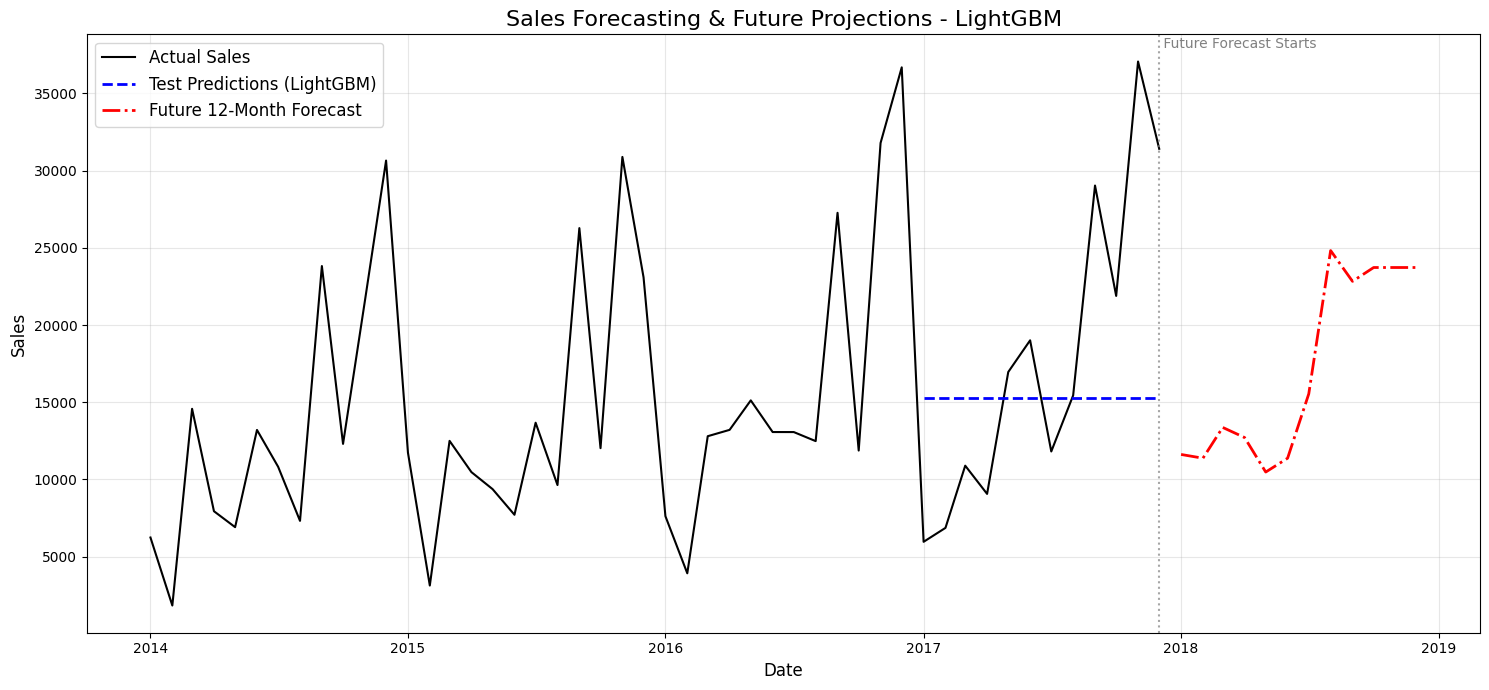

In [27]:
# ==========================================
# EXECUTION
# ==========================================

# Run the pipeline and plot all 5 models sequentially
generate_and_plot_all_models(df_ts, test_size=12, future_steps=12, lags=3)

## Unificied plotting 

In [37]:
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pandas as pd

def plot_all_forecasts_unified(df_ts, all_test_preds, all_future_preds, mape_results):
    """
    Plots historical data alongside test and future forecasts for all models on a single graph,
    including the MAPE score in the legend.
    """
    plt.figure(figsize=(18, 10))
    
    # 1. Plot Actual Historical Data
    plt.plot(df_ts.index, df_ts['Sales'], label='Actual Sales', color='black', linewidth=3)
    
    # Define a distinct color palette
    colors = {
        "AutoARIMA": "#1f77b4",             # Blue
        "Exponential Smoothing": "#2ca02c", # Green
        "Prophet": "#9467bd",               # Purple
        "XGBoost": "#ff7f0e",               # Orange
        "LightGBM": "#d62728"               # Red
    }
    
    # 2. Plot Test Predictions (Dashed Lines - no legend to avoid duplicate labels)
    for model_name, test_preds in all_test_preds.items():
        color = colors.get(model_name, "gray")
        plt.plot(test_preds.index, test_preds, 
                 color=color, linestyle='--', linewidth=1.5, alpha=0.7)
        
    # 3. Plot Future Forecasts (Solid Lines - WITH MAPE IN LEGEND)
    for model_name, future_preds in all_future_preds.items():
        color = colors.get(model_name, "gray")
        mape_score = mape_results.get(model_name, 0)
        
        # Format the legend label to include the MAPE score
        label_text = f'{model_name} Forecast (MAPE: {mape_score:.4f})'
        
        plt.plot(future_preds.index, future_preds, label=label_text, 
                 color=color, linestyle='-', linewidth=2.5)
    
    # Formatting
    plt.title('Comprehensive Sales Forecasting & Projections (All Models)', fontsize=20, pad=15)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Sales', fontsize=14)
    
    plt.axvline(x=df_ts.index[-1], color='gray', linestyle=':', linewidth=2.5)
    plt.text(df_ts.index[-1] + pd.DateOffset(days=5), plt.ylim()[1]*0.95, 
             'Future Forecast Starts \u2192', color='dimgray', ha='left', fontsize=12, fontweight='bold')
    
    plt.legend(fontsize=12, loc='upper left', framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [40]:
def generate_and_plot_all_models(df_ts, test_size=12, future_steps=12, lags=3):
    """
    Trains each model, stores their predictions, calculates MAPE, 
    and plots them on a single unified graph with scores in the legend.
    """
    train = df_ts.iloc[:-test_size]
    test = df_ts.iloc[-test_size:]
    future_index = pd.date_range(start=df_ts.index[-1] + pd.DateOffset(months=1), periods=future_steps, freq='MS')
    
    all_test_preds = {}
    all_future_preds = {}
    
    # ---------------------------------------------------------
    # 1. AutoARIMA
    # ---------------------------------------------------------
    print("Processing AutoARIMA...")
    arima_train = pm.auto_arima(train['Sales'], seasonal=True, m=12, suppress_warnings=True)
    all_test_preds["AutoARIMA"] = pd.Series(arima_train.predict(n_periods=test_size).values, index=test.index)
    
    arima_full = pm.auto_arima(df_ts['Sales'], seasonal=True, m=12, suppress_warnings=True)
    all_future_preds["AutoARIMA"] = pd.Series(arima_full.predict(n_periods=future_steps).values, index=future_index)

    # ---------------------------------------------------------
    # 2. Exponential Smoothing
    # ---------------------------------------------------------
    print("Processing Exponential Smoothing...")
    hw_train = ExponentialSmoothing(train['Sales'], trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
    all_test_preds["Exponential Smoothing"] = hw_train.forecast(test_size)
    
    hw_full = ExponentialSmoothing(df_ts['Sales'], trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
    all_future_preds["Exponential Smoothing"] = hw_full.forecast(future_steps)

    # ---------------------------------------------------------
    # 3. Prophet
    # ---------------------------------------------------------
    print("Processing Prophet...")
    prophet_train_df = train.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    m_train = Prophet(seasonality_mode='multiplicative').fit(prophet_train_df)
    future_test = m_train.make_future_dataframe(periods=test_size, freq='MS')
    test_preds_prophet = m_train.predict(future_test)['yhat'].tail(test_size)
    test_preds_prophet.index = test.index
    all_test_preds["Prophet"] = test_preds_prophet
    
    prophet_full_df = df_ts.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    m_full = Prophet(seasonality_mode='multiplicative').fit(prophet_full_df)
    future_full = m_full.make_future_dataframe(periods=future_steps, freq='MS')
    future_preds_prophet = m_full.predict(future_full)['yhat'].tail(future_steps)
    future_preds_prophet.index = future_index
    all_future_preds["Prophet"] = future_preds_prophet

    # ---------------------------------------------------------
    # 4 & 5. Machine Learning Models (XGBoost & LightGBM)
    # ---------------------------------------------------------
    df_ml = create_ml_features(df_ts, lags=lags)
    train_ml = df_ml.iloc[:-test_size]
    
    X_train, y_train = train_ml.drop(columns=['Sales']), train_ml['Sales']
    X_full, y_full = df_ml.drop(columns=['Sales']), df_ml['Sales']

    models = {
        "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
        "LightGBM": lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbose=-1)
    }

    for name, model in models.items():
        print(f"Processing {name}...")
        
        model.fit(X_train, y_train)
        test_preds_ml = recursive_ml_forecast(model, train['Sales'], steps=test_size, lags=lags)
        test_preds_ml.index = test.index 
        all_test_preds[name] = test_preds_ml
        
        model.fit(X_full, y_full)
        all_future_preds[name] = recursive_ml_forecast(model, df_ts['Sales'], steps=future_steps, lags=lags)
        
    # ---------------------------------------------------------
    # Final Step: Calculate MAPE & Plot
    # ---------------------------------------------------------
    print("Calculating MAPE and generating unified plot...")
    
    mape_results = {}
    for model_name, test_preds in all_test_preds.items():
        mape_score = mean_absolute_percentage_error(test['Sales'], test_preds)
        mape_results[model_name] = mape_score
        
    # Pass the calculated MAPE results to the plotting function
    plot_all_forecasts_unified(df_ts, all_test_preds, all_future_preds, mape_results)
   

--- Time Series EDA ---


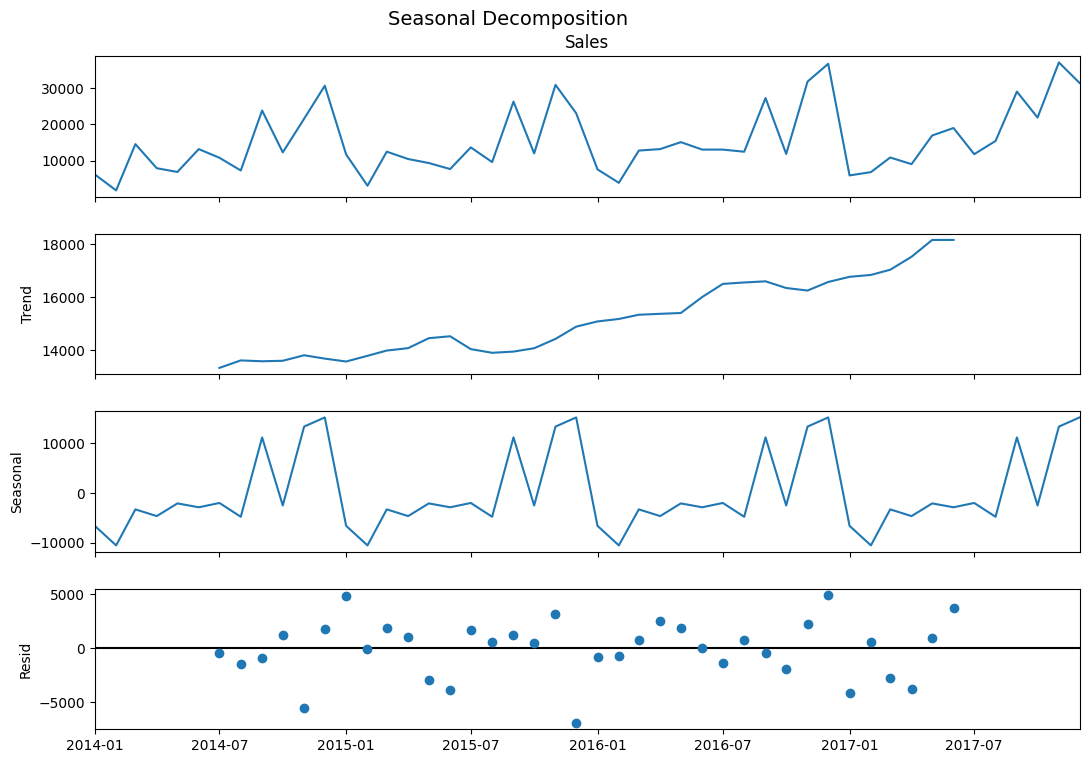

ADF Statistic: -4.6990
p-value: 0.0001
Conclusion: Data is STATIONARY (Reject Null Hypothesis)
Processing AutoARIMA...


14:06:06 - cmdstanpy - INFO - Chain [1] start processing
14:06:06 - cmdstanpy - INFO - Chain [1] done processing


Processing Exponential Smoothing...
Processing Prophet...


14:06:06 - cmdstanpy - INFO - Chain [1] start processing
14:06:06 - cmdstanpy - INFO - Chain [1] done processing


Processing XGBoost...
Processing LightGBM...
Calculating MAPE and generating unified plot...


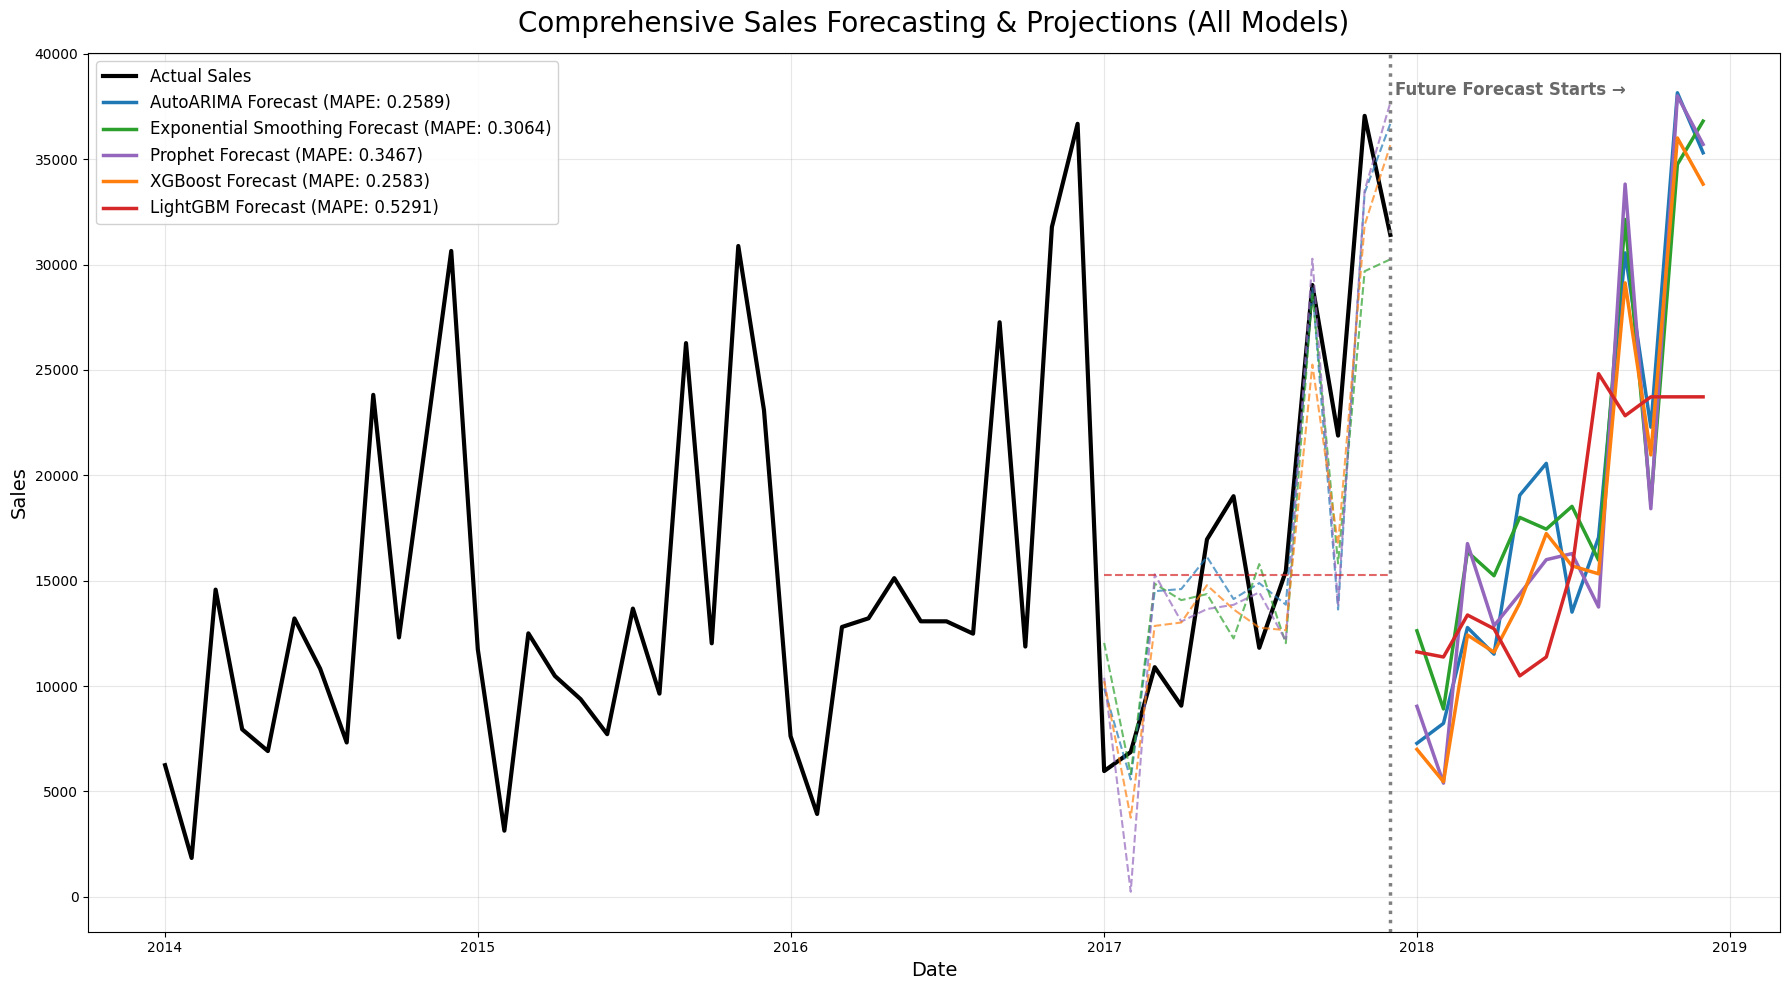

In [41]:
# ==========================================
# FINAL EXECUTION BLOCK - RUN THIS
# ==========================================

# 1. First, preprocess your raw dataframe (assuming your raw data is named 'df')
# This aggregates it to monthly sales
df_ts = preprocess_data(df, target_col='Sales', date_col='Order Date', freq='MS')

# 2. (Optional) Run the EDA to see trend/stationarity
perform_eda(df_ts, target_col='Sales')

# 3. Run the modeling pipeline which will train, calculate MAPE, and show the giant plot
generate_and_plot_all_models(df_ts, test_size=12, future_steps=12, lags=3)

In [36]:
 plot_all_forecasts_unified(df_ts, all_test_preds, all_future_preds, mape_results)

NameError: name 'all_test_preds' is not defined

## Pro[phet HP tuning ]

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid
import logging
import warnings

# Suppress Prophet's verbose logging during the massive grid search
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

def granular_prophet_tuning(df_ts, test_size=12):
    """
    Performs a highly granular grid search for Prophet forecasting.
    Evaluates all combinations on a test set and returns a sorted DataFrame of all MAPEs.
    """
    print(f"Starting granular Prophet tuning (Test Size: {test_size} months)...")
    
    # 1. Train/Test Split & Prophet Formatting
    train = df_ts.iloc[:-test_size]
    test = df_ts.iloc[-test_size:]
    
    df_train_prophet = train.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    df_test_prophet = test.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    
    # 2. Define Granular Hyperparameter Grid
    # Total combinations: 5 * 5 * 2 * 2 = 100 iterations
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5], # Controls trend flexibility
        'seasonality_prior_scale': [0.01, 0.1, 1.0, 5.0, 10.0],   # Controls seasonality flexibility
        'seasonality_mode': ['additive', 'multiplicative'],       # How seasonality impacts trend
        'changepoint_range': [0.8, 0.95]                          # Proportion of history where trend can change
    }
    
    grid = ParameterGrid(param_grid)
    results = []
    
    total_iters = len(grid)
    print(f"Total hyperparameter combinations to test: {total_iters}")
    
    # 3. Iterate through every combination
    for i, params in enumerate(grid, 1):
        if i % 10 == 0:
            print(f"Running iteration {i}/{total_iters}...")
            
        try:
            # Initialize model with current parameters
            m = Prophet(**params)
            
            # Fit model
            m.fit(df_train_prophet)
            
            # Predict
            future = m.make_future_dataframe(periods=test_size, freq='MS')
            forecast = m.predict(future)
            
            # Extract test predictions
            preds = forecast['yhat'].tail(test_size)
            
            # Calculate MAPE
            mape = mean_absolute_percentage_error(df_test_prophet['y'], preds)
            
            # Store results
            result_row = params.copy()
            result_row['MAPE'] = mape
            results.append(result_row)
            
        except Exception as e:
            print(f"Error on iteration {i} with params {params}: {e}")
            continue
            
    # 4. Compile and Sort Results
    results_df = pd.DataFrame(results)
    
    # Reorder columns to put MAPE first for readability
    cols = ['MAPE'] + [col for col in results_df.columns if col != 'MAPE']
    results_df = results_df[cols]
    
    # Sort by MAPE ascending (lowest error first)b
    results_df = results_df.sort_values(by='MAPE', ascending=True).reset_index(drop=True)
    
    print("\n--- Tuning Complete ---")
    return results_df

In [43]:
# ==========================================
# EXECUTION
# ==========================================

# Run the tuning function on your preprocessed time series dataframe (df_ts)
all_prophet_variations = granular_prophet_tuning(df_ts, test_size=12)

# Display the Top 10 Best Configurations
print("\n🏆 Top 10 Prophet Configurations:")
print(all_prophet_variations.head(10).to_string())

# Display the Worst 5 Configurations (to see what didn't work)
print("\n❌ Bottom 5 Prophet Configurations:")
print(all_prophet_variations.tail(5).to_string())

# Optional: If you want to save ALL 100 variations to a CSV for your records
# all_prophet_variations.to_csv('prophet_tuning_results.csv', index=False)

Starting granular Prophet tuning (Test Size: 12 months)...
Total hyperparameter combinations to test: 100
Running iteration 10/100...
Running iteration 20/100...
Running iteration 30/100...
Running iteration 40/100...
Running iteration 50/100...
Running iteration 60/100...
Running iteration 70/100...
Running iteration 80/100...
Running iteration 90/100...
Running iteration 100/100...

--- Tuning Complete ---

🏆 Top 10 Prophet Configurations:
       MAPE  changepoint_prior_scale  changepoint_range seasonality_mode  seasonality_prior_scale
0  0.293080                    0.001               0.80         additive                      1.0
1  0.293681                    0.001               0.95         additive                      1.0
2  0.294903                    0.001               0.80         additive                      5.0
3  0.294904                    0.001               0.95         additive                      5.0
4  0.295359                    0.010               0.80         

In [48]:
import logging
import warnings
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.model_selection import ParameterGrid

# Suppress verbose CMDStanPy/Prophet logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")


def wmape(y_true, y_pred):
    """Calculates Weighted Mean Absolute Percentage Error (handles zeros safely)."""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


def robust_prophet_tuning_daily_to_monthly(df_daily, test_size_days=365):
    """Trains Prophet on daily data, forecasts daily, aggregates test predictions

    to a monthly level, and evaluates using WMAPE.
    """
    print(
        f"Starting tuning: Train (Daily) -> Predict (Daily) -> Eval"
        f" (Monthly)..."
    )

    # 1. Train/Test Split
    train = df_daily.iloc[:-test_size_days]
    test = df_daily.iloc[-test_size_days:]

    df_train_prophet = train.reset_index().rename(
        columns={"Order Date": "ds", "Sales": "y"}
    )
    df_test_prophet = test.reset_index().rename(
        columns={"Order Date": "ds", "Sales": "y"}
    )

    # 2. Additive-only grid search to prevent multiplicative zero-collapse
    param_grid = {
        "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5],
        "seasonality_prior_scale": [0.01, 0.1, 1.0, 5.0, 10.0],
        "seasonality_mode": ["additive"],
        "changepoint_range": [0.8, 0.95],
    }

    grid = ParameterGrid(param_grid)
    results = []
    total_iters = len(grid)

    print(f"Total hyperparameter combinations to test: {total_iters}\n")

    # 3. Iterate through parameters
    for i, params in enumerate(grid, 1):
        if i % 10 == 0 or i == total_iters:
            print(f"Running iteration {i}/{total_iters}...")

        try:
            m = Prophet(**params)
            m.fit(df_train_prophet)

            future = m.make_future_dataframe(
                periods=test_size_days, freq="D"
            )
            forecast = m.predict(future)

            # Extract test window predictions
            preds_df = forecast[["ds", "yhat"]].tail(test_size_days).copy()
            actuals_df = df_test_prophet[["ds", "y"]].copy()

            merged = pd.merge(actuals_df, preds_df, on="ds").set_index("ds")

            # Aggregate to Monthly
            monthly_agg = merged.resample("MS").sum()

            # Calculate score
            score = wmape(monthly_agg["y"], monthly_agg["yhat"])

            result_row = params.copy()
            result_row["WMAPE"] = score
            results.append(result_row)

        except Exception as e:
            continue

    # 4. Compile and Sort
    results_df = pd.DataFrame(results)
    cols = ["WMAPE"] + [
        col for col in results_df.columns if col != "WMAPE"
    ]
    results_df = (
        results_df[cols]
        .sort_values(by="WMAPE", ascending=True)
        .reset_index(drop=True)
    )

    print("\n--- Tuning Complete ---")
    return results_df

In [49]:
# ==========================================
# DATA PREPROCESSING & EXECUTION
# ==========================================

# 1. Preprocess raw dataframe 'df' into a daily continuous time series
df["Order Date"] = pd.to_datetime(df["Order Date"])
df_daily = df.groupby("Order Date")["Sales"].sum().reset_index()
df_daily.set_index("Order Date", inplace=True)
df_daily = df_daily.resample("D").sum().fillna(0)  # Ensure non-zero date grid

# 2. Run the tuning function (testing against a 365-day holdout)
prophet_results = robust_prophet_tuning_daily_to_monthly(
    df_daily, test_size_days=365
)

# 3. Output top results
print("\n🏆 Top 10 Prophet Configurations (Lowest WMAPE):")
print(prophet_results.head(10).to_string())

Starting tuning: Train (Daily) -> Predict (Daily) -> Eval (Monthly)...
Total hyperparameter combinations to test: 50

Running iteration 10/50...
Running iteration 20/50...
Running iteration 30/50...
Running iteration 40/50...
Running iteration 50/50...

--- Tuning Complete ---

🏆 Top 10 Prophet Configurations (Lowest WMAPE):
      WMAPE  changepoint_prior_scale  changepoint_range seasonality_mode  seasonality_prior_scale
0  0.202619                    0.010               0.80         additive                      1.0
1  0.202798                    0.010               0.80         additive                     10.0
2  0.203516                    0.010               0.95         additive                     10.0
3  0.203823                    0.010               0.80         additive                      0.1
4  0.203878                    0.010               0.95         additive                      5.0
5  0.204384                    0.001               0.80         additive             

## Prophet daily - more tuning
 

In [50]:
import logging
import warnings
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.model_selection import ParameterGrid

# Suppress verbose CMDStanPy/Prophet logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")


def wmape(y_true, y_pred):
    """Calculates Weighted Mean Absolute Percentage Error (handles zeros safely)."""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


def enlarged_prophet_tuning_daily_to_monthly(df_daily, test_size_days=365):
    """
    Trains Prophet on daily data with an expanded hyperparameter grid 
    (including Fourier orders and changepoints), forecasts daily, 
    aggregates test predictions to monthly, and evaluates using WMAPE.
    """
    print(
        f"Starting enlarged tuning: Train (Daily) -> Predict (Daily) -> Eval (Monthly)..."
    )

    # 1. Train/Test Split
    train = df_daily.iloc[:-test_size_days]
    test = df_daily.iloc[-test_size_days:]

    df_train_prophet = train.reset_index().rename(
        columns={"Order Date": "ds", "Sales": "y"}
    )
    df_test_prophet = test.reset_index().rename(
        columns={"Order Date": "ds", "Sales": "y"}
    )

    # 2. Expanded Grid Search
    # Note: additive is kept to prevent the zero-collapse issue
    param_grid = {
        "changepoint_prior_scale": [0.01, 0.05, 0.1],
        "seasonality_prior_scale": [0.1, 1.0, 10.0],
        "changepoint_range": [0.8, 0.95],
        "n_changepoints": [15, 25],  # Number of potential trend change points
        "yearly_fourier_order": [5, 10, 15],  # Default is 10
        "weekly_fourier_order": [3, 5],       # Default is 3
        "seasonality_mode": ["additive"]
    }

    grid = ParameterGrid(param_grid)
    results = []
    total_iters = len(grid)

    print(f"Total hyperparameter combinations to test: {total_iters}\n")

    # 3. Iterate through parameters
    for i, params_dict in enumerate(grid, 1):
        if i % 10 == 0 or i == total_iters:
            print(f"Running iteration {i}/{total_iters}...")

        try:
            # Copy params so we can pop custom keys without modifying the original dict
            params = params_dict.copy()
            y_fourier = params.pop("yearly_fourier_order")
            w_fourier = params.pop("weekly_fourier_order")

            # Initialize Prophet, disabling defaults so we can apply custom Fourier orders
            m = Prophet(
                yearly_seasonality=False,
                weekly_seasonality=False,
                daily_seasonality=False,
                **params
            )
            
            # Add seasonalities with the tuned Fourier orders
            m.add_seasonality(name="yearly", period=365.25, fourier_order=y_fourier)
            m.add_seasonality(name="weekly", period=7, fourier_order=w_fourier)
            
            m.fit(df_train_prophet)

            future = m.make_future_dataframe(periods=test_size_days, freq="D")
            forecast = m.predict(future)

            # Extract test window predictions
            preds_df = forecast[["ds", "yhat"]].tail(test_size_days).copy()
            actuals_df = df_test_prophet[["ds", "y"]].copy()

            merged = pd.merge(actuals_df, preds_df, on="ds").set_index("ds")

            # Aggregate to Monthly
            monthly_agg = merged.resample("MS").sum()

            # Calculate score
            score = wmape(monthly_agg["y"], monthly_agg["yhat"])

            # Save the original params_dict (which includes the fourier keys) to results
            result_row = params_dict.copy()
            result_row["WMAPE"] = score
            results.append(result_row)

        except Exception as e:
            continue

    # 4. Compile and Sort
    results_df = pd.DataFrame(results)
    cols = ["WMAPE"] + [
        col for col in results_df.columns if col != "WMAPE"
    ]
    results_df = (
        results_df[cols]
        .sort_values(by="WMAPE", ascending=True)
        .reset_index(drop=True)
    )

    print("\n--- Tuning Complete ---")
    return results_df

In [51]:
# ==========================================
# DATA PREPROCESSING & EXECUTION
# ==========================================

# 1. Preprocess raw dataframe 'df' into a daily continuous time series
df["Order Date"] = pd.to_datetime(df["Order Date"])
df_daily = df.groupby("Order Date")["Sales"].sum().reset_index()
df_daily.set_index("Order Date", inplace=True)
df_daily = df_daily.resample("D").sum().fillna(0)  # Ensure non-zero date grid

# 2. Run the expanded tuning function (testing against a 365-day holdout)
prophet_expanded_results = enlarged_prophet_tuning_daily_to_monthly(
    df_daily, test_size_days=365
)

# 3. Output top results
print("\n🏆 Top 10 Prophet Configurations (Expanded Grid):")
print(prophet_expanded_results.head(10).to_string())

Starting enlarged tuning: Train (Daily) -> Predict (Daily) -> Eval (Monthly)...
Total hyperparameter combinations to test: 216

Running iteration 10/216...
Running iteration 20/216...
Running iteration 30/216...
Running iteration 40/216...
Running iteration 50/216...
Running iteration 60/216...
Running iteration 70/216...
Running iteration 80/216...
Running iteration 90/216...
Running iteration 100/216...
Running iteration 110/216...
Running iteration 120/216...
Running iteration 130/216...
Running iteration 140/216...
Running iteration 150/216...
Running iteration 160/216...
Running iteration 170/216...
Running iteration 180/216...
Running iteration 190/216...
Running iteration 200/216...
Running iteration 210/216...
Running iteration 216/216...

--- Tuning Complete ---

🏆 Top 10 Prophet Configurations (Expanded Grid):
      WMAPE  changepoint_prior_scale  changepoint_range  n_changepoints seasonality_mode  seasonality_prior_scale  weekly_fourier_order  yearly_fourier_order
0  0.18587

## LSTM and  Xgboost 

In [52]:
import numpy as np
import pandas as pd
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. Feature Engineering
# ---------------------------------------------------------
def create_ml_features(history, target_date=None):
    """
    Calculates calendar, lag, EWMA, and Rolling Std features.
    If target_date is provided, it appends a dummy row to calculate features 
    for the exact step we are trying to predict.
    """
    df_feat = history.to_frame(name='Sales')
    
    if target_date:
        df_feat.loc[target_date] = np.nan
        
    df_feat['DayOfWeek'] = df_feat.index.dayofweek
    df_feat['Month'] = df_feat.index.month
    
    # Lags
    for lag in [1, 7, 30]:
        df_feat[f'Lag_{lag}'] = df_feat['Sales'].shift(lag)
        
    # EWMA of past lags (shift 1 prevents data leakage from the current day)
    df_feat['EWMA_7'] = df_feat['Sales'].shift(1).ewm(span=7).mean()
    df_feat['EWMA_30'] = df_feat['Sales'].shift(1).ewm(span=30).mean()
    
    # Standard Deviation of past lags
    df_feat['Std_7'] = df_feat['Sales'].shift(1).rolling(window=7).std()
    df_feat['Std_30'] = df_feat['Sales'].shift(1).rolling(window=30).std()
    
    if target_date:
        return df_feat.iloc[-1:] # Return only the row for the target date
    
    return df_feat.dropna()

# ---------------------------------------------------------
# 2. Main ML Pipeline
# ---------------------------------------------------------
def run_daily_ml_pipeline(df_daily, test_size_days=365):
    print("--- Preparing Data & Features ---")
    
    # Split raw data
    train_raw = df_daily.iloc[:-test_size_days]
    test_raw = df_daily.iloc[-test_size_days:]
    
    # Generate Training Features
    train_features = create_ml_features(train_raw)
    feature_cols = [c for c in train_features.columns if c != 'Sales']
    
    X_train = train_features[feature_cols]
    y_train = train_features['Sales']
    
    # Scale features (Required for LSTM)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # ---------------------------------------------------------
    # 3. Train Models
    # ---------------------------------------------------------
    print("--- Training XGBoost ---")
    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
    xgb_model.fit(X_train, y_train)
    
    print("--- Training LSTM ---")
    # Reshape for LSTM: (samples, time_steps, features)
    X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    
    lstm_model = Sequential()
    lstm_model.add(LSTM(50, activation='relu', input_shape=(1, len(feature_cols))))
    lstm_model.add(Dense(1))
    lstm_model.compile(optimizer='adam', loss='mse')
    # verbose=0 keeps the output clean
    lstm_model.fit(X_train_lstm, y_train, epochs=30, batch_size=32, verbose=0) 
    
    # ---------------------------------------------------------
    # 4. Recursive Forecasting (Daily)
    # ---------------------------------------------------------
    print("--- Generating Recursive Daily Forecasts ---")
    history_series = train_raw.copy()
    
    xgb_preds, lstm_preds, ens_preds = [], [], []
    future_dates = test_raw.index
    
    for i, date in enumerate(future_dates):
        if i % 30 == 0:
            print(f"Predicting step {i}/{len(future_dates)}...")
            
        # Get features for the current step based on dynamically updated history
        X_step = create_ml_features(history_series, target_date=date)[feature_cols]
        
        # XGBoost Prediction
        xgb_p = max(0, xgb_model.predict(X_step)[0])
        xgb_preds.append(xgb_p)
        
        # LSTM Prediction
        X_step_scaled = scaler.transform(X_step)
        X_step_lstm = X_step_scaled.reshape((1, 1, len(feature_cols)))
        lstm_p = max(0, lstm_model.predict(X_step_lstm, verbose=0)[0][0])
        lstm_preds.append(lstm_p)
        
        # Ensemble Prediction (Simple Average)
        ens_p = (xgb_p + lstm_p) / 2
        ens_preds.append(ens_p)
        
        # VERY IMPORTANT: Append the Ensemble prediction to the history 
        # so the next step's Lags/EWMA/Std are based on this forecast
        history_series.loc[date] = ens_p

    # ---------------------------------------------------------
    # 5. Aggregate to Monthly & Calculate MAPE
    # ---------------------------------------------------------
    print("--- Aggregating to Monthly & Calculating MAPE ---")
    df_results_daily = pd.DataFrame({
        'Actual': test_raw,
        'XGBoost': xgb_preds,
        'LSTM': lstm_preds,
        'Ensemble': ens_preds
    }, index=future_dates)
    
    # Resample daily results to monthly
    monthly_results = df_results_daily.resample('MS').sum()
    
    mape_scores = {
        'XGBoost': mean_absolute_percentage_error(monthly_results['Actual'], monthly_results['XGBoost']),
        'LSTM': mean_absolute_percentage_error(monthly_results['Actual'], monthly_results['LSTM']),
        'Ensemble': mean_absolute_percentage_error(monthly_results['Actual'], monthly_results['Ensemble'])
    }
    
    # Also aggregate historical data for plotting
    historical_monthly = df_daily.resample('MS').sum()
    
    return historical_monthly, monthly_results, mape_scores

# ---------------------------------------------------------
# 6. Plotting Function
# ---------------------------------------------------------
def plot_ml_forecasts(historical_monthly, monthly_results, mape_scores):
    plt.figure(figsize=(16, 8))
    
    # Plot historical actuals
    plt.plot(historical_monthly.index, historical_monthly, label='Historical Actuals', color='black', linewidth=2)
    
    # Plot test actuals
    plt.plot(monthly_results.index, monthly_results['Actual'], label='Test Actuals', color='gray', linestyle='--', linewidth=2)
    
    # Plot Models
    plt.plot(monthly_results.index, monthly_results['XGBoost'], 
             label=f"XGBoost (MAPE: {mape_scores['XGBoost']:.4f})", color='#ff7f0e', linewidth=2)
             
    plt.plot(monthly_results.index, monthly_results['LSTM'], 
             label=f"LSTM (MAPE: {mape_scores['LSTM']:.4f})", color='#1f77b4', linewidth=2)
             
    plt.plot(monthly_results.index, monthly_results['Ensemble'], 
             label=f"Ensemble (MAPE: {mape_scores['Ensemble']:.4f})", color='#2ca02c', linewidth=3)
    
    plt.title('Monthly Sales Forecast: XGBoost vs LSTM vs Ensemble', fontsize=18)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Monthly Sales', fontsize=12)
    
    # Vertical line separating train and test
    split_date = monthly_results.index[0]
    plt.axvline(x=split_date, color='red', linestyle=':', linewidth=2)
    plt.text(split_date + pd.DateOffset(days=5), plt.ylim()[1]*0.9, 'Test Set Starts \u2192', color='red', fontweight='bold')
    
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================
# DATA PREPROCESSING & EXECUTION
# ==========================================

# 1. Preprocess raw dataframe 'df' into a daily continuous time series
df["Order Date"] = pd.to_datetime(df["Order Date"])
df_daily = df.groupby("Order Date")["Sales"].sum().reset_index()
df_daily.set_index("Order Date", inplace=True)
df_daily = df_daily.resample("D").sum().fillna(0)  # Ensure non-zero date grid

# 2. Run the pipeline (testing against a 365-day holdout)
historical_monthly, monthly_results, mape_scores = run_daily_ml_pipeline(df_daily['Sales'], test_size_days=365)

# 3. Output results
print("\n🏆 MAPE Results (Monthly Aggregation):")
for model, score in mape_scores.items():
    print(f"{model}: {score:.4f}")

# 4. Generate the plot
plot_ml_forecasts(historical_monthly, monthly_results, mape_scores)

--- Preparing Data & Features ---
--- Training XGBoost ---
--- Training LSTM ---
